# PepperAI — Black Pepper Disease Detection (CNN Training)### Local version — Anaconda + NVIDIA RTX GPU### EfficientNet-B0 transfer learning + Grad-CAM explainability**Before running this notebook:**1. Make sure you've created the conda environment and installed packages (see setup instructions provided separately).2. Unzip `pepperai_dataset.zip` somewhere on your computer and note the folder path.3. Update the `DATA_ROOT` path in Step 2 below to match where you unzipped it.4. Run cells top to bottom (Shift+Enter).

## Step 1 — Check GPU is detected

In [2]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU detected:", torch.cuda.get_device_name(0))
else:
    print("WARNING: No GPU detected. Check your PyTorch install used the CUDA version.")
    

CUDA available: True
GPU detected: NVIDIA GeForce RTX 2050


## Step 2 — Point to your dataset folder**EDIT THE PATH BELOW** to wherever you unzipped `pepperai_dataset.zip` on your computer.Examples:- Windows: `r"C:\Users\YourName\Downloads\data_final"`- Mac/Linux: `"/Users/YourName/Downloads/data_final"`

In [7]:
import os

DATA_ROOT = r"D:\PepperAI\pepperai_dataset\data_final"

assert os.path.exists(DATA_ROOT), f"Path not found: {DATA_ROOT} -- check you unzipped the dataset and updated this path."
print("Classes found:", sorted(os.listdir(os.path.join(DATA_ROOT, 'train'))))

Classes found: ['foot_rot', 'healthy', 'leaf_blight', 'pollu_disease', 'slow_decline', 'yellow_mottle_virus']


## Step 3 — Verify the dataset (quick sanity check)

In [9]:
for split in ['train','val','test']:
    print(f"--- {split} ---")
    for cls in sorted(os.listdir(os.path.join(DATA_ROOT, split))):
        n = len(os.listdir(os.path.join(DATA_ROOT, split, cls)))
        print(f"  {cls}: {n} images")

--- train ---
  foot_rot: 339 images
  healthy: 191 images
  leaf_blight: 191 images
  pollu_disease: 339 images
  slow_decline: 350 images
  yellow_mottle_virus: 191 images
--- val ---
  foot_rot: 72 images
  healthy: 40 images
  leaf_blight: 40 images
  pollu_disease: 72 images
  slow_decline: 75 images
  yellow_mottle_virus: 40 images
--- test ---
  foot_rot: 74 images
  healthy: 42 images
  leaf_blight: 42 images
  pollu_disease: 74 images
  slow_decline: 75 images
  yellow_mottle_virus: 42 images


## Step 4 — Build data loaders (with augmentation)

In [10]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(os.path.join(DATA_ROOT, 'train'), transform=train_transform)
val_ds   = datasets.ImageFolder(os.path.join(DATA_ROOT, 'val'),   transform=eval_transform)
test_ds  = datasets.ImageFolder(os.path.join(DATA_ROOT, 'test'),  transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

CLASS_NAMES = train_ds.classes
print("Classes (index order matters!):", CLASS_NAMES)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Classes (index order matters!): ['foot_rot', 'healthy', 'leaf_blight', 'pollu_disease', 'slow_decline', 'yellow_mottle_virus']
Train: 1601 | Val: 339 | Test: 349


## Step 5 — Build the model (EfficientNet-B0, transfer learning)

In [11]:
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

weights = EfficientNet_B0_Weights.IMAGENET1K_V1
model = efficientnet_b0(weights=weights)

for param in model.features.parameters():
    param.requires_grad = False

num_classes = len(CLASS_NAMES)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

model = model.to(device)
print(model.classifier)

Using device: cuda


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\vojes/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:02<00:00, 8.39MB/s]


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=6, bias=True)
)


## Step 6 — Set up training (loss function + optimizer)

In [13]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

## Step 7 — Training loopOn an RTX GPU this should take roughly 1-3 minutes total for 15 epochs.Saves the best model (by validation accuracy) as `best_model.pt` in this notebook's folder.

In [17]:
import copy
import time

NUM_EPOCHS = 15
best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss, running_correct, total = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        running_correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    train_loss = running_loss / total
    train_acc = running_correct / total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += labels.size(0)
    val_loss = val_loss / val_total
    val_acc = val_correct / val_total

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | train_loss={train_loss:.4f} train_acc={train_acc:.3f} | val_loss={val_loss:.4f} val_acc={val_acc:.3f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), 'best_model.pt')
elapsed = time.time() - start_time
print(f"\nTraining took {elapsed:.1f} seconds")
print(f"Best validation accuracy: {best_val_acc:.3f} -- saved to best_model.pt")

Epoch 1/15 | train_loss=0.1933 train_acc=0.949 | val_loss=0.1395 val_acc=0.973
Epoch 2/15 | train_loss=0.1984 train_acc=0.949 | val_loss=0.1189 val_acc=0.971
Epoch 3/15 | train_loss=0.1995 train_acc=0.943 | val_loss=0.1224 val_acc=0.971
Epoch 4/15 | train_loss=0.1887 train_acc=0.949 | val_loss=0.1400 val_acc=0.971
Epoch 5/15 | train_loss=0.1904 train_acc=0.946 | val_loss=0.1162 val_acc=0.968
Epoch 6/15 | train_loss=0.1856 train_acc=0.948 | val_loss=0.1118 val_acc=0.979
Epoch 7/15 | train_loss=0.1874 train_acc=0.947 | val_loss=0.1008 val_acc=0.982
Epoch 8/15 | train_loss=0.1912 train_acc=0.943 | val_loss=0.1227 val_acc=0.971
Epoch 9/15 | train_loss=0.1766 train_acc=0.955 | val_loss=0.0945 val_acc=0.985
Epoch 10/15 | train_loss=0.1923 train_acc=0.947 | val_loss=0.1139 val_acc=0.976
Epoch 11/15 | train_loss=0.1933 train_acc=0.946 | val_loss=0.1421 val_acc=0.968
Epoch 12/15 | train_loss=0.1747 train_acc=0.957 | val_loss=0.1016 val_acc=0.976
Epoch 13/15 | train_loss=0.1689 train_acc=0.954 |

## Step 8 — Plot training curves

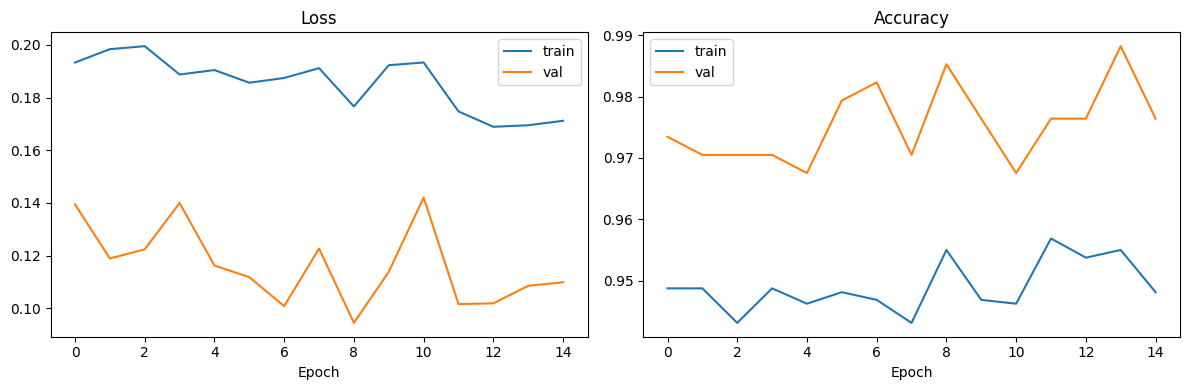

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history['train_acc'], label='train')
axes[1].plot(history['val_acc'], label='val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.savefig('training_curves.png', dpi=120)
plt.show()

## Step 9 — Final evaluation on the TEST set

                     precision    recall  f1-score   support

           foot_rot       0.94      1.00      0.97        74
            healthy       0.93      1.00      0.97        42
        leaf_blight       0.98      1.00      0.99        42
      pollu_disease       1.00      0.96      0.98        74
       slow_decline       1.00      0.93      0.97        75
yellow_mottle_virus       1.00      0.98      0.99        42

           accuracy                           0.97       349
          macro avg       0.97      0.98      0.98       349
       weighted avg       0.98      0.97      0.97       349



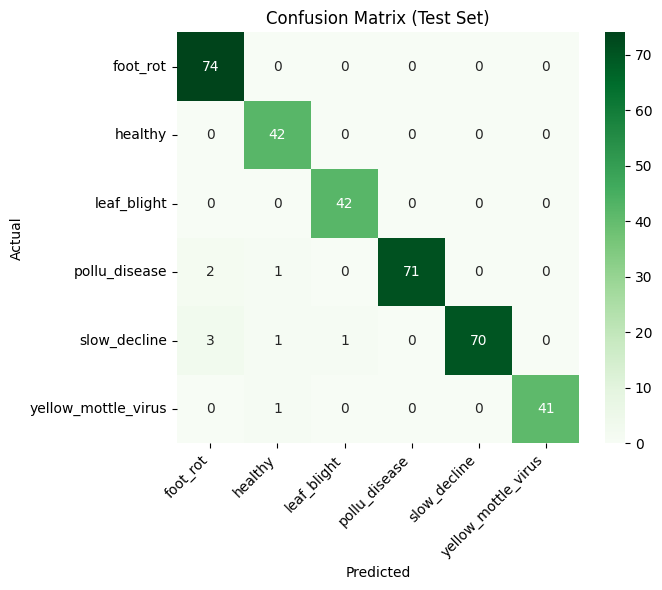

In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Greens')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix (Test Set)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()

## Step 10 — Explainable AI: Grad-CAMInstall grad-cam first if you haven't: `pip install grad-cam`

True label: foot_rot


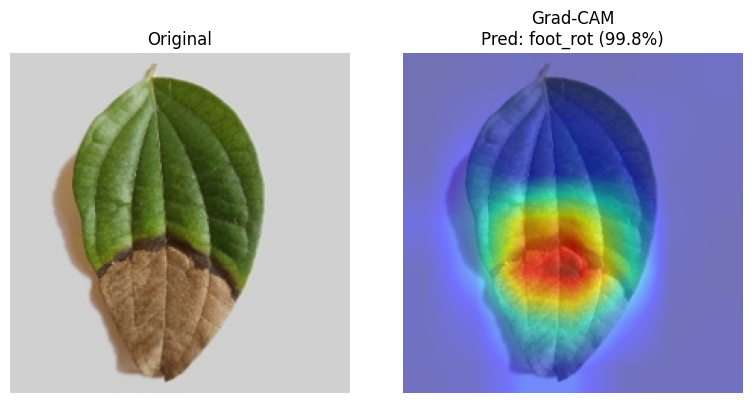

True label: healthy


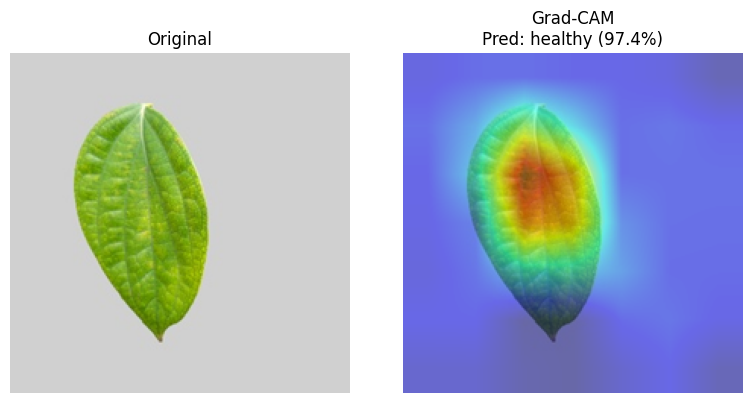

True label: leaf_blight


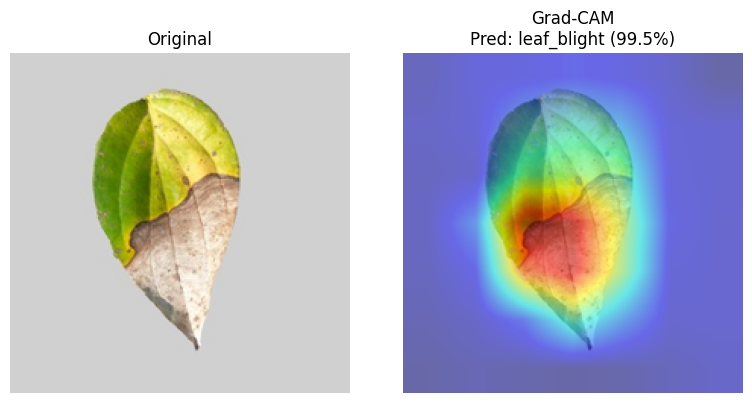

True label: pollu_disease


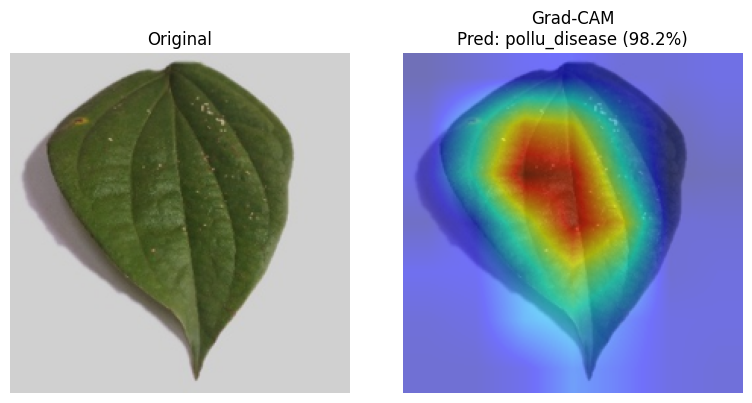

True label: slow_decline


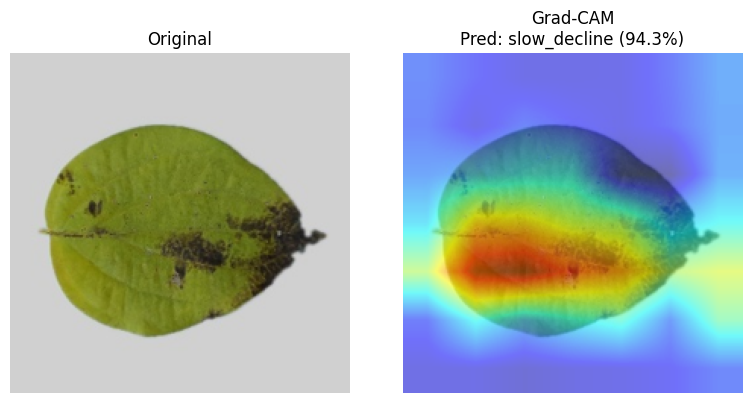

True label: yellow_mottle_virus


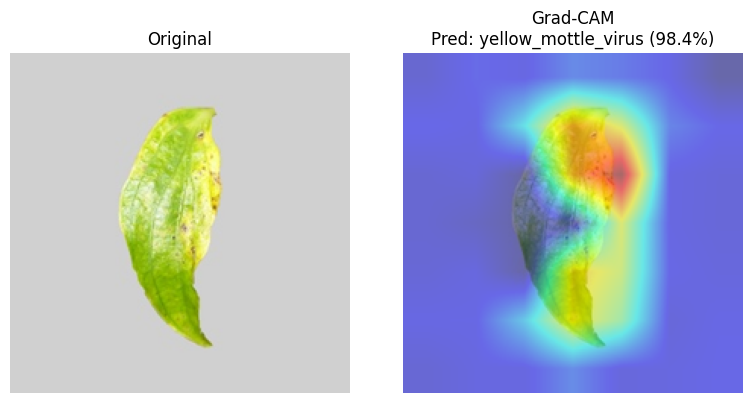

In [21]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from PIL import Image
import numpy as np

target_layers = [model.features[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

def show_gradcam(img_path, true_label=None):
    img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    img_np = np.array(img).astype(np.float32) / 255.0
    input_tensor = eval_transform(Image.open(img_path).convert('RGB')).unsqueeze(0).to(device)
    input_tensor.requires_grad_(True)

    outputs = model(input_tensor)
    pred_idx = outputs.argmax(1).item()
    confidence = torch.softmax(outputs, dim=1)[0][pred_idx].item()

    grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0]
    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    fig, axes = plt.subplots(1, 2, figsize=(8,4))
    axes[0].imshow(img); axes[0].set_title('Original'); axes[0].axis('off')
    axes[1].imshow(visualization); axes[1].set_title(f'Grad-CAM\nPred: {CLASS_NAMES[pred_idx]} ({confidence:.1%})'); axes[1].axis('off')
    plt.tight_layout()
    plt.show()

import random
test_files = []
for cls in CLASS_NAMES:
    folder = os.path.join(DATA_ROOT, 'test', cls)
    f = random.choice(os.listdir(folder))
    test_files.append((os.path.join(folder, f), cls))

for path, true_cls in test_files:
    print(f"True label: {true_cls}")
    show_gradcam(path)

## Step 11 — Your trained model is saved locally`best_model.pt`, `confusion_matrix.png`, and `training_curves.png` are already savedin the same folder as this notebook -- no download step needed since everything ran locally.You'll need `best_model.pt` later for the website backend.